In [7]:
import os
from dotenv import load_dotenv

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace

import matplotlib.pyplot as plt

load_dotenv("/home/jovyan/work/.env")

MONGO_URI = os.getenv("MONGO_URI")
DB_NAME = os.getenv("DB_NAME")
PROCESSED_COLLECTION = os.getenv("PROCESSED_COLLECTION")

spark = (
    SparkSession.builder
    .appName("Boxplot_Anomalias_Jocelyn")
    .config("spark.mongodb.read.connection.uri", MONGO_URI)
    .config("spark.mongodb.write.connection.uri", MONGO_URI)
    .config(
        "spark.jars.packages",
        "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1"
    )
    .getOrCreate()
)

df = (
    spark.read.format("mongodb")
    .option("database", DB_NAME)
    .option("collection", PROCESSED_COLLECTION)
    .load()
)

print("Base de datos:", DB_NAME)
print("Colección:", PROCESSED_COLLECTION)
print("Registros cargados:", df.count())

Base de datos: proyecto_bigdata
Colección: Contenedor_Autos_Limpio
Registros cargados: 1988


In [8]:
df_clean = df.select(
    "marca",
    "modelo",
    "precio",
    "year",
    "kilometraje",
    "url"
).dropDuplicates(["url"])

df_clean = df_clean.filter(col("precio").isNotNull())

df_clean = df_clean.withColumn(
    "precio_num",
    regexp_replace(col("precio"), "[^0-9]", "").cast("double")
)

df_clean = df_clean.filter(col("precio_num") > 0)

print("Registros válidos para boxplot:", df_clean.count())

df_clean.select(
    "marca",
    "modelo",
    "precio",
    "precio_num"
).show(10, truncate=False)

Registros válidos para boxplot: 1988
+-----+----------------------------+-------+----------+
|marca|modelo                      |precio |precio_num|
+-----+----------------------------+-------+----------+
|audi |A1 Sportback 30 Tfsi Sport  |2.199E7|21997.0   |
|audi |A1 Sportback 30 Tfsi Sport  |2.199E7|21997.0   |
|audi |A3 2.0 Tfsi Sport Auto      |1.899E7|18997.0   |
|audi |A3 1.4 35 Tfsi Stronic Auto |1.589E7|15897.0   |
|audi |A4 2.0 Tfsi 35 S-tronic     |2.949E7|29497.0   |
|audi |A5 New 2.0 Tfsi Quattro S Li|5.499E7|54997.0   |
|audi |A6 2.0 Turbo                |1.297E7|12977.0   |
|audi |E-tron Bev 95kwh 55 Quattro |5.799E7|57997.0   |
|audi |Q2 1.4 35 Tfsi Stronic Auto |2.499E7|24997.0   |
|audi |Q3                          |1.598E7|15987.0   |
+-----+----------------------------+-------+----------+
only showing top 10 rows



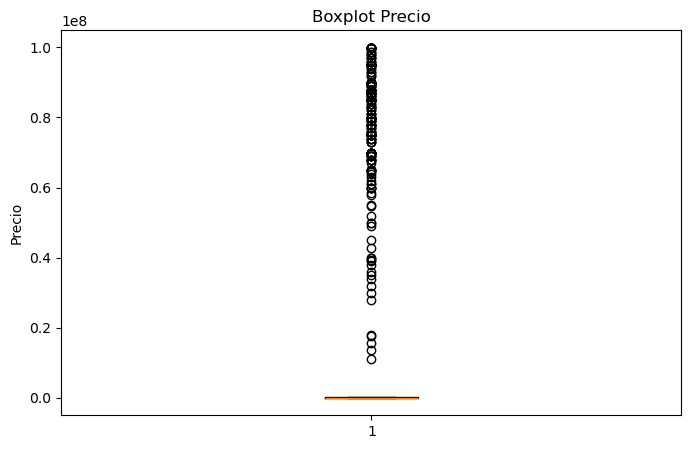

In [9]:
box_pd = df_clean.select(
    "precio_num"
).dropna().limit(1000).toPandas()

plt.figure(figsize=(8,5))

plt.boxplot(box_pd["precio_num"])

plt.title("Boxplot Precio")
plt.ylabel("Precio")

plt.show()

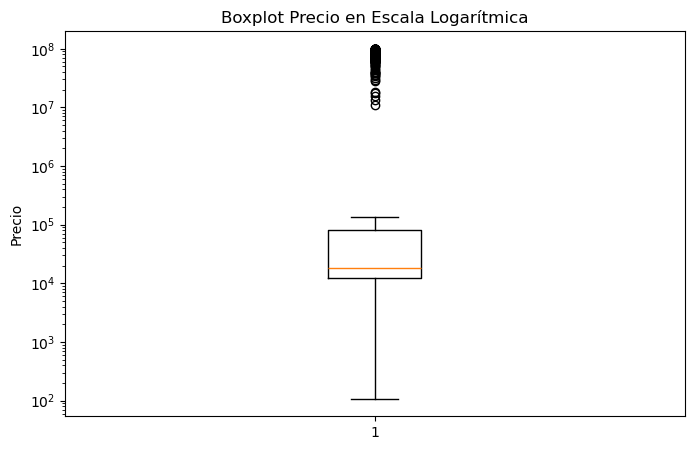

In [10]:
plt.figure(figsize=(8,5))

plt.boxplot(box_pd["precio_num"])

plt.yscale("log")

plt.title("Boxplot Precio en Escala Logarítmica")
plt.ylabel("Precio")

plt.show()

## Interpretación Boxplot

El boxplot permite identificar posibles valores atípicos dentro de la variable precio. En el conjunto de datos de AutoTec, se observa que la mayoría de los vehículos se concentra en rangos de precio más bajos, mientras que existen registros con valores considerablemente superiores.

Estos valores atípicos pueden corresponder a vehículos premium, modelos más recientes, autos de alta gama o unidades con características particulares que justifican un valor comercial mayor.

Desde una perspectiva de negocio, detectar estos outliers es relevante porque pueden afectar los resultados de análisis posteriores, especialmente en modelos de segmentación o predicción de precios. Por esta razón, es importante reconocerlos y analizarlos antes de tomar decisiones basadas en el comportamiento promedio del mercado.